## 04 Threshold Evaluation

This notebook converts similarity scores into binary overlap decisions for the shortlisted model and text-variant configurations selected in Notebook 03.

### Main goal

The purpose of Notebook 04 is to evaluate **decision quality**.

It answers:

> Which embedding model and similarity threshold combination optimally balances precision and recall for curriculum overlap detection?

### What this notebook does

- loads the long-format pair similarity scores from Notebook 03
- loads the shortlist of configurations selected for threshold evaluation
- evaluates threshold behavior on the **development split**
- identifies candidate thresholds for each configuration
- compares threshold strategies such as:
  - maximum F1
  - precision-oriented threshold
  - reviewer-load-oriented threshold
- prepares locked threshold candidates for later held-out test evaluation

### What this notebook does not do yet

- it does not retune embeddings
- it does not re-rank models from scratch
- it does not use the test set for threshold selection
- it does not yet claim the final winner before held-out evaluation

### Important methodological note

Thresholds are selected using the **development split only**.

The **test split must remain locked** until threshold selection is complete. This is necessary to preserve a meaningful held-out evaluation.

### Evaluation context from Notebook 03

The shortlisted configurations come from a course-level split with:

- development pairs: 595
- development positives: 23
- test pairs: 105
- test positives: 5

Because the test set still contains only a small number of positive pairs, final test metrics must be interpreted cautiously.

In [36]:
# Cell 02 - Import libraries and define project paths

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "thresholds"
TABLES_DIR = REPORTS_DIR / "tables" / "thresholds"
BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
BENCHMARK_TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"

PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
SHORTLIST_CSV_PATH = BENCHMARK_TABLES_DIR / "shortlist_for_notebook_04.csv"

THRESHOLD_SCAN_CSV_PATH = TABLES_DIR / "threshold_scan_dev.csv"
CANDIDATE_THRESHOLDS_CSV_PATH = TABLES_DIR / "candidate_thresholds_dev.csv"
SELECTED_THRESHOLDS_CSV_PATH = TABLES_DIR / "selected_thresholds_for_test.csv"
DEV_THRESHOLD_SUMMARY_CSV_PATH = TABLES_DIR / "dev_threshold_summary.csv"

for path in [FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Pair scores CSV:", PAIR_SCORES_CSV_PATH)
print("Shortlist CSV:", SHORTLIST_CSV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Pair scores CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Shortlist CSV: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\thresholds
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds


### Load benchmark outputs

This notebook uses:

- the long-format similarity score table from Notebook 03
- the shortlisted configurations selected for threshold evaluation

In [37]:
# Cell 04 - Load benchmark outputs

if PAIR_SCORES_PARQUET_PATH.exists():
    pair_scores_long_df = pd.read_parquet(PAIR_SCORES_PARQUET_PATH)
else:
    pair_scores_long_df = pd.read_csv(PAIR_SCORES_CSV_PATH, encoding="utf-8")

shortlist_df = pd.read_csv(SHORTLIST_CSV_PATH, encoding="utf-8")

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("shortlist_df shape:", shortlist_df.shape)

display(pair_scores_long_df.head(3))
display(shortlist_df.head(10))

pair_scores_long_df shape: (10500, 12)
shortlist_df shape: (5, 16)


,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,split,model_name,text_variant,similarity_score,embedding_dim,encoding_seconds
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,TT00CD71,Linux Basics,0,test,tfidf,compact,0.194746,4092,0.322446
1,TT00CD70__TT00CD76,TT00CD70,Data Networks,TT00CD76,Scripting and Automatization,0,test,tfidf,compact,0.124798,4092,0.322446
2,TT00CD70__TT00CD77,TT00CD70,Data Networks,TT00CD77,Basics of Programming,0,test,tfidf,compact,0.142908,4092,0.322446


,model_name,text_variant,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,shortlist_rank
0,multilingual-e5-large,with_prerequisites,595,21,574,0.035294,0.937562,0.900744,0.036818,0.938471,0.899970,0.038501,0.726140,20.573974,0.976190,1
1,openai_text-embedding-3-large,with_prerequisites,595,21,574,0.035294,0.685292,0.465004,0.220288,0.687776,0.452466,0.235310,0.707060,20.033373,0.979094,2
2,multilingual-e5-large,main,595,21,574,0.035294,0.927989,0.891070,0.036919,0.930202,0.889993,0.040209,0.650668,18.435597,0.956280,3
3,bge-m3,with_prerequisites,595,21,574,0.035294,0.752957,0.617600,0.135356,0.746244,0.613092,0.133152,0.636988,18.048007,0.962585,4
4,multilingual-e5-base,with_prerequisites,595,21,574,0.035294,0.934155,0.902366,0.031789,0.935275,0.901882,0.033394,0.574757,16.284794,0.949643,5


In [38]:
# Cell 05 - Validate required columns

required_pair_score_columns = [
    "pair_id",
    "overlap_label_binary",
    "split",
    "model_name",
    "text_variant",
    "similarity_score",
]

required_shortlist_columns = [
    "model_name",
    "text_variant",
]

missing_pair_score_columns = [col for col in required_pair_score_columns if col not in pair_scores_long_df.columns]
missing_shortlist_columns = [col for col in required_shortlist_columns if col not in shortlist_df.columns]

if missing_pair_score_columns:
    raise ValueError(f"Missing required pair score columns: {missing_pair_score_columns}")

if missing_shortlist_columns:
    raise ValueError(f"Missing required shortlist columns: {missing_shortlist_columns}")

if pair_scores_long_df["split"].isna().any():
    raise ValueError("Found missing split values in pair_scores_long_df.")

print("All required columns are present.")

All required columns are present.


### Filter to shortlisted configurations

Notebook 04 evaluates only the shortlisted configurations from Notebook 03. This keeps threshold analysis focused and avoids unnecessary repetition.

In [39]:
# Cell 07 - Filter the long-format score table to shortlisted configurations

shortlist_keys_df = shortlist_df[["model_name", "text_variant"]].drop_duplicates().copy()

evaluation_scores_df = pair_scores_long_df.merge(
    shortlist_keys_df,
    on=["model_name", "text_variant"],
    how="inner",
)

if evaluation_scores_df.empty:
    raise ValueError("No rows remained after filtering to shortlisted configurations.")

print("evaluation_scores_df shape:", evaluation_scores_df.shape)
display(
    evaluation_scores_df[["model_name", "text_variant"]]
    .drop_duplicates()
    .sort_values(["model_name", "text_variant"])
    .reset_index(drop=True)
)

evaluation_scores_df shape: (3500, 12)


,model_name,text_variant
0,bge-m3,with_prerequisites
1,multilingual-e5-base,with_prerequisites
2,multilingual-e5-large,main
3,multilingual-e5-large,with_prerequisites
4,openai_text-embedding-3-large,with_prerequisites


### Verify split context

Before threshold tuning begins, verify the number of pairs and positives in the development and test splits for the shortlisted configurations.

In [40]:
# Cell 09 - Verify split context

split_context_df = (
    evaluation_scores_df
    .groupby(["model_name", "text_variant", "split"])["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
    .reset_index()
    .sort_values(["model_name", "text_variant", "split"])
    .reset_index(drop=True)
)

display(split_context_df)

dev_pair_count_check = evaluation_scores_df.loc[evaluation_scores_df["split"] == "dev", "pair_id"].nunique()
dev_positive_count_check = evaluation_scores_df.loc[
    evaluation_scores_df["split"] == "dev"
].drop_duplicates(subset=["pair_id"])["overlap_label_binary"].sum()

test_pair_count_check = evaluation_scores_df.loc[evaluation_scores_df["split"] == "test", "pair_id"].nunique()
test_positive_count_check = evaluation_scores_df.loc[
    evaluation_scores_df["split"] == "test"
].drop_duplicates(subset=["pair_id"])["overlap_label_binary"].sum()

print("Unique dev pairs:", int(dev_pair_count_check))
print("Unique dev positives:", int(dev_positive_count_check))
print("Unique test pairs:", int(test_pair_count_check))
print("Unique test positives:", int(test_positive_count_check))

,model_name,text_variant,split,count,positive_count
0,bge-m3,with_prerequisites,dev,595,21
1,bge-m3,with_prerequisites,test,105,5
2,multilingual-e5-base,with_prerequisites,dev,595,21
3,multilingual-e5-base,with_prerequisites,test,105,5
4,multilingual-e5-large,main,dev,595,21
5,multilingual-e5-large,main,test,105,5
6,multilingual-e5-large,with_prerequisites,dev,595,21
7,multilingual-e5-large,with_prerequisites,test,105,5
8,openai_text-embedding-3-large,with_prerequisites,dev,595,21
9,openai_text-embedding-3-large,with_prerequisites,test,105,5


Unique dev pairs: 595
Unique dev positives: 21
Unique test pairs: 105
Unique test positives: 5


### Threshold evaluation helpers

Threshold scanning is performed on the **development split only**.

For each threshold, the notebook computes:

- precision
- recall
- F1
- accuracy
- specificity
- predicted positive count
- confusion-matrix counts

These metrics will later support both statistical and practical threshold decisions.

In [41]:
# Cell 11 - Threshold evaluation helper functions

def compute_confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def compute_threshold_metrics(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)

    counts = compute_confusion_counts(y_true, y_pred)

    specificity = counts["tn"] / (counts["tn"] + counts["fp"]) if (counts["tn"] + counts["fp"]) > 0 else np.nan

    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "specificity": specificity,
        "predicted_positive_count": int(y_pred.sum()),
        "tn": counts["tn"],
        "fp": counts["fp"],
        "fn": counts["fn"],
        "tp": counts["tp"],
    }

def build_threshold_grid(y_score: np.ndarray, max_points: int = 400) -> np.ndarray:
    """
    Build a threshold grid using the observed score range.

    The grid includes:
    - all unique score values if the number is small enough
    - otherwise a dense linear grid across the observed range
    """
    unique_scores = np.unique(np.round(y_score, 10))

    if len(unique_scores) <= max_points:
        grid = unique_scores
    else:
        grid = np.linspace(y_score.min(), y_score.max(), max_points)

    # Include a value just above max score so predicted positives can drop to zero if needed
    epsilon = 1e-9
    grid = np.unique(np.concatenate([grid, [y_score.max() + epsilon]]))

    return np.sort(grid)

def slugify_name(text: str) -> str:
    return text.lower().replace("/", "_").replace(" ", "_")

### Build threshold scan table on development split

For each shortlisted configuration, scan thresholds across the observed similarity-score range and record decision metrics on the development split.

In [42]:
# Cell 13 - Build threshold scan table on development split

dev_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("Development split is empty after shortlist filtering.")

threshold_scan_rows = []

for (model_name, text_variant), group_df in dev_scores_df.groupby(["model_name", "text_variant"]):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    threshold_grid = build_threshold_grid(y_score=y_score, max_points=400)

    for threshold in threshold_grid:
        metrics = compute_threshold_metrics(y_true=y_true, y_score=y_score, threshold=threshold)

        threshold_scan_rows.append({
            "model_name": model_name,
            "text_variant": text_variant,
            "pair_count_dev": len(group_df),
            "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
            **metrics,
        })

threshold_scan_dev_df = pd.DataFrame(threshold_scan_rows)

if threshold_scan_dev_df.empty:
    raise ValueError("threshold_scan_dev_df is empty.")

threshold_scan_dev_df.to_csv(THRESHOLD_SCAN_CSV_PATH, index=False, encoding="utf-8")

print("Saved threshold scan table to:", THRESHOLD_SCAN_CSV_PATH)
print("threshold_scan_dev_df shape:", threshold_scan_dev_df.shape)

display(threshold_scan_dev_df.head(10))

Saved threshold scan table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\threshold_scan_dev.csv
threshold_scan_dev_df shape: (2005, 15)


,model_name,text_variant,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,with_prerequisites,595,21,0.489761,0.035294,1.0,0.068182,0.035294,0.000000,595,0,574,0,21
1,bge-m3,with_prerequisites,595,21,0.490636,0.035354,1.0,0.068293,0.036975,0.001742,594,1,573,0,21
2,bge-m3,with_prerequisites,595,21,0.491511,0.035413,1.0,0.068404,0.038655,0.003484,593,2,572,0,21
3,bge-m3,with_prerequisites,595,21,0.492386,0.035413,1.0,0.068404,0.038655,0.003484,593,2,572,0,21
4,bge-m3,with_prerequisites,595,21,0.493260,0.035413,1.0,0.068404,0.038655,0.003484,593,2,572,0,21
5,bge-m3,with_prerequisites,595,21,0.494135,0.035413,1.0,0.068404,0.038655,0.003484,593,2,572,0,21
6,bge-m3,with_prerequisites,595,21,0.495010,0.035473,1.0,0.068515,0.040336,0.005226,592,3,571,0,21
7,bge-m3,with_prerequisites,595,21,0.495885,0.035473,1.0,0.068515,0.040336,0.005226,592,3,571,0,21
8,bge-m3,with_prerequisites,595,21,0.496759,0.035473,1.0,0.068515,0.040336,0.005226,592,3,571,0,21
9,bge-m3,with_prerequisites,595,21,0.497634,0.035473,1.0,0.068515,0.040336,0.005226,592,3,571,0,21


### Inspect threshold scan summary

This summary helps confirm that each shortlisted configuration has a valid threshold scan and gives a first view of score-range differences across model families.

In [43]:
# Cell 15 - Threshold scan summary by configuration

threshold_scan_summary_df = (
    threshold_scan_dev_df
    .groupby(["model_name", "text_variant"])
    .agg(
        threshold_count=("threshold", "count"),
        threshold_min=("threshold", "min"),
        threshold_max=("threshold", "max"),
        max_f1=("f1", "max"),
        max_precision=("precision", "max"),
        max_recall=("recall", "max"),
        min_predicted_positive_count=("predicted_positive_count", "min"),
        max_predicted_positive_count=("predicted_positive_count", "max"),
    )
    .reset_index()
    .sort_values(["max_f1", "max_precision"], ascending=[False, False])
    .reset_index(drop=True)
)

display(threshold_scan_summary_df)

,model_name,text_variant,threshold_count,threshold_min,threshold_max,max_f1,max_precision,max_recall,min_predicted_positive_count,max_predicted_positive_count
0,openai_text-embedding-3-large,with_prerequisites,401,0.289874,0.769665,0.680851,1.0,1.0,0,595
1,multilingual-e5-large,with_prerequisites,401,0.867014,0.952032,0.648649,1.0,1.0,0,595
2,multilingual-e5-large,main,401,0.857573,0.953899,0.625000,1.0,1.0,0,595
3,multilingual-e5-base,with_prerequisites,401,0.867081,0.961862,0.611111,1.0,1.0,0,595
4,bge-m3,with_prerequisites,401,0.489761,0.838782,0.603774,1.0,1.0,0,595


### Candidate threshold selection on development split

For each configuration, identify at least three candidate thresholds:

- **max-F1 threshold**
- **precision-oriented threshold**
- **reviewer-load threshold**

These are still selected on the development split only.

In [44]:
# Cell 17 - Select candidate thresholds from the development threshold scan

candidate_threshold_rows = []

for (model_name, text_variant), group_df in threshold_scan_dev_df.groupby(["model_name", "text_variant"]):
    working_df = group_df.sort_values("threshold").reset_index(drop=True)

    # A. Max-F1 threshold
    max_f1_idx = working_df["f1"].idxmax()
    max_f1_row = working_df.loc[max_f1_idx]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "selection_rule": "max_f1",
        **max_f1_row.to_dict(),
    })

    # B. Precision-oriented threshold
    # Rule: among thresholds with recall >= 0.30, choose the highest precision.
    precision_first_pool = working_df[working_df["recall"] >= 0.30].copy()

    if precision_first_pool.empty:
        precision_first_pool = working_df.copy()

    precision_first_pool = precision_first_pool.sort_values(
        ["precision", "recall", "f1", "threshold"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    precision_first_row = precision_first_pool.iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "selection_rule": "precision_first",
        **precision_first_row.to_dict(),
    })

    # C. Reviewer-load threshold
    # Rule: choose the threshold with predicted positive count closest to 10 on dev,
    # preferring higher precision and F1 if ties occur.
    reviewer_target = 10
    reviewer_pool = working_df.copy()
    reviewer_pool["reviewer_load_distance"] = (reviewer_pool["predicted_positive_count"] - reviewer_target).abs()

    reviewer_pool = reviewer_pool.sort_values(
        ["reviewer_load_distance", "precision", "f1", "threshold"],
        ascending=[True, False, False, True]
    ).reset_index(drop=True)

    reviewer_row = reviewer_pool.iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "selection_rule": "reviewer_load",
        **reviewer_row.drop(labels=["reviewer_load_distance"]).to_dict(),
    })

candidate_thresholds_dev_df = pd.DataFrame(candidate_threshold_rows)

candidate_thresholds_dev_df.to_csv(CANDIDATE_THRESHOLDS_CSV_PATH, index=False, encoding="utf-8")

print("Saved candidate thresholds to:", CANDIDATE_THRESHOLDS_CSV_PATH)
display(candidate_thresholds_dev_df)

Saved candidate thresholds to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\candidate_thresholds_dev.csv


,model_name,text_variant,selection_rule,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,with_prerequisites,max_f1,595,21,0.727691,0.500000,0.761905,0.603774,0.964706,0.972125,32,558,16,5,16
1,bge-m3,with_prerequisites,precision_first,595,21,0.769678,0.888889,0.380952,0.533333,0.976471,0.998258,9,573,1,13,8
2,bge-m3,with_prerequisites,reviewer_load,595,21,0.768803,0.800000,0.380952,0.516129,0.974790,0.996516,10,572,2,13,8
3,multilingual-e5-base,with_prerequisites,max_f1,595,21,0.935257,0.733333,0.523810,0.611111,0.976471,0.993031,15,570,4,10,11
4,multilingual-e5-base,with_prerequisites,precision_first,595,21,0.938345,0.777778,0.333333,0.466667,0.973109,0.996516,9,572,2,14,7
5,multilingual-e5-base,with_prerequisites,reviewer_load,595,21,0.938107,0.700000,0.333333,0.451613,0.971429,0.994774,10,571,3,14,7
6,multilingual-e5-large,main,max_f1,595,21,0.933620,0.909091,0.476190,0.625000,0.979832,0.998258,11,573,1,11,10
7,multilingual-e5-large,main,precision_first,595,21,0.935551,1.000000,0.380952,0.551724,0.978151,1.000000,8,574,0,13,8
8,multilingual-e5-large,main,reviewer_load,595,21,0.934827,0.900000,0.428571,0.580645,0.978151,0.998258,10,573,1,12,9
9,multilingual-e5-large,with_prerequisites,max_f1,595,21,0.936904,0.750000,0.571429,0.648649,0.978151,0.993031,16,570,4,9,12


### Threshold behavior plots

These plots are essential for understanding threshold stability.

For each shortlisted configuration, inspect:

- threshold vs precision
- threshold vs recall
- threshold vs F1
- threshold vs predicted positive count

This is especially important for compressed-score models such as multilingual E5.

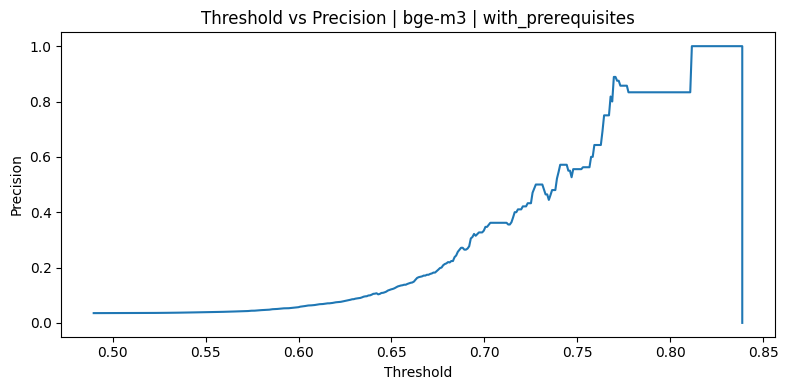

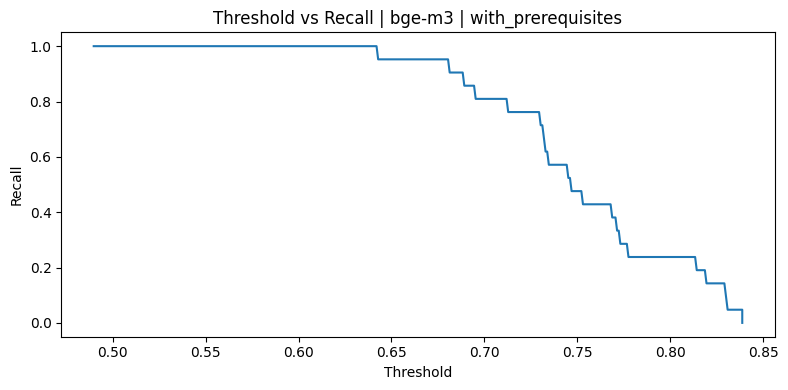

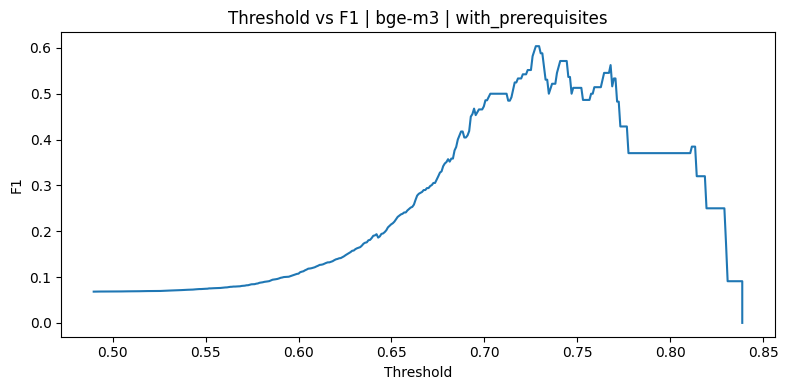

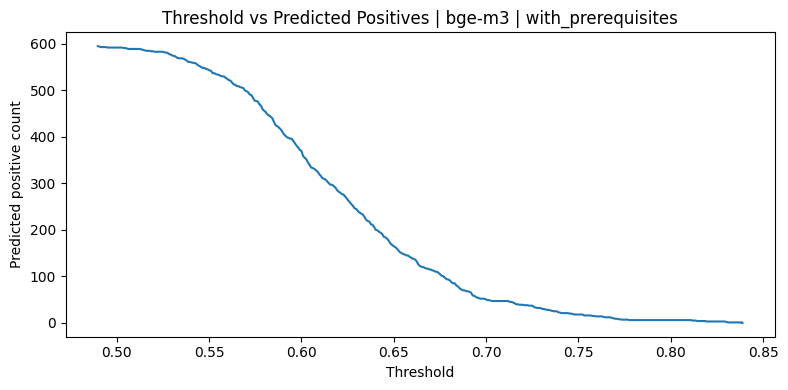

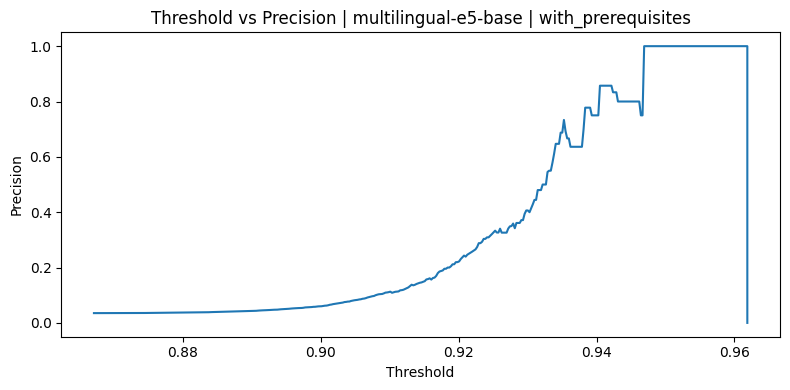

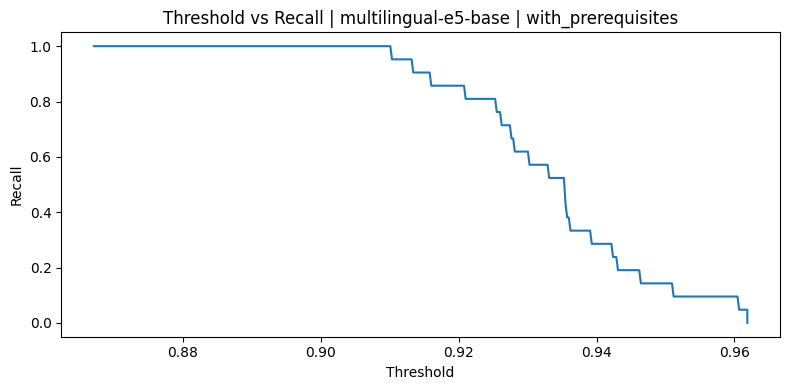

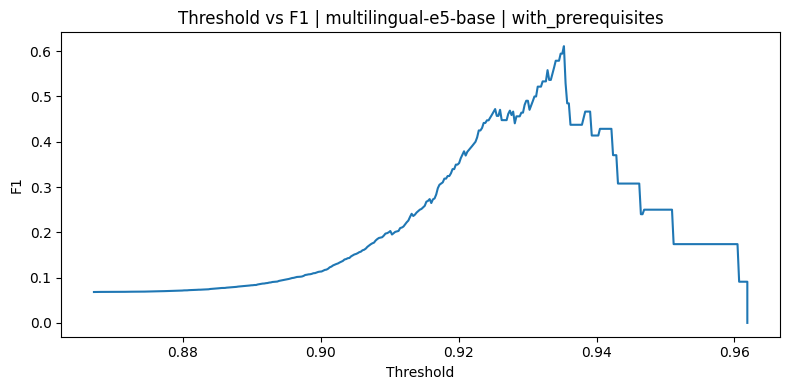

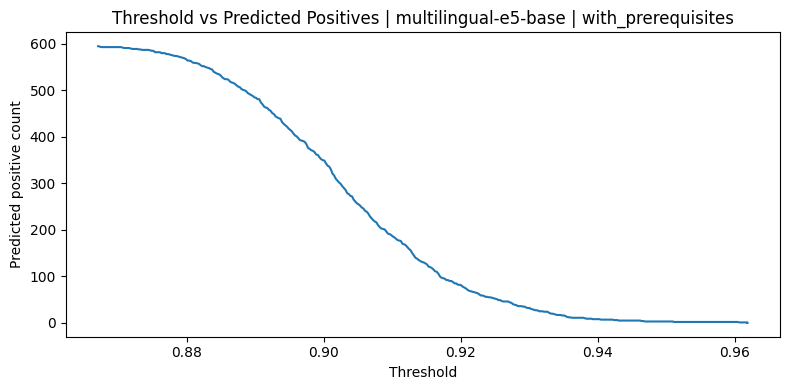

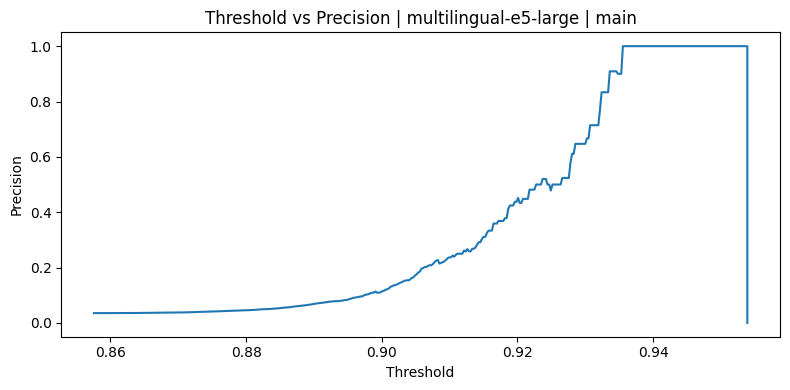

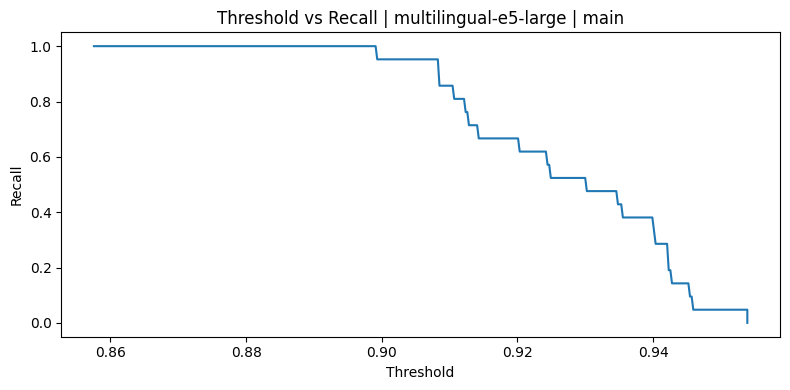

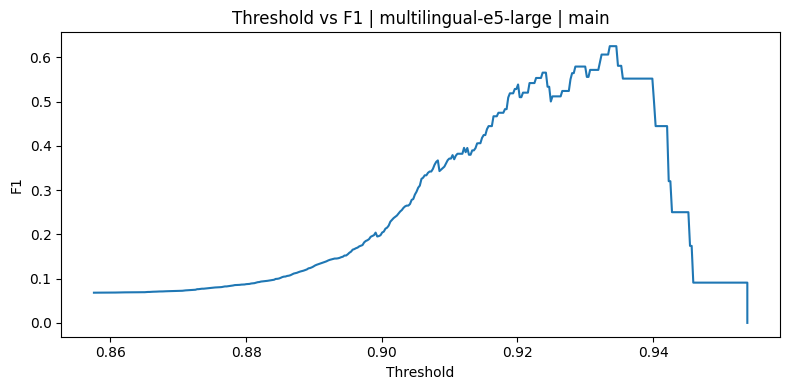

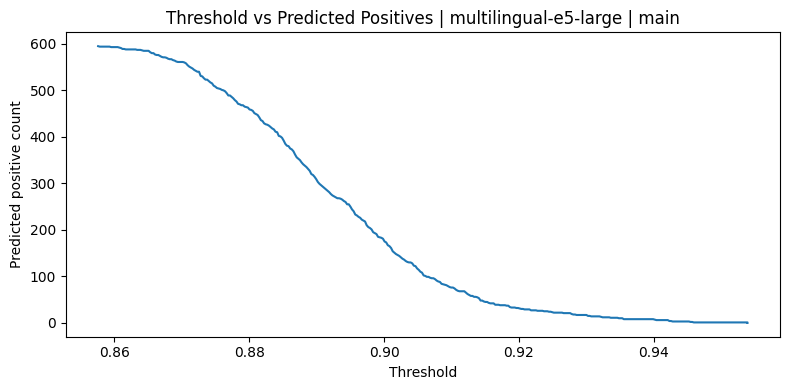

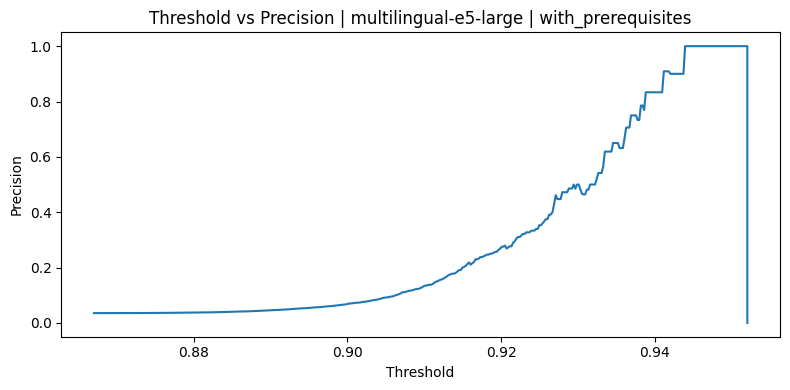

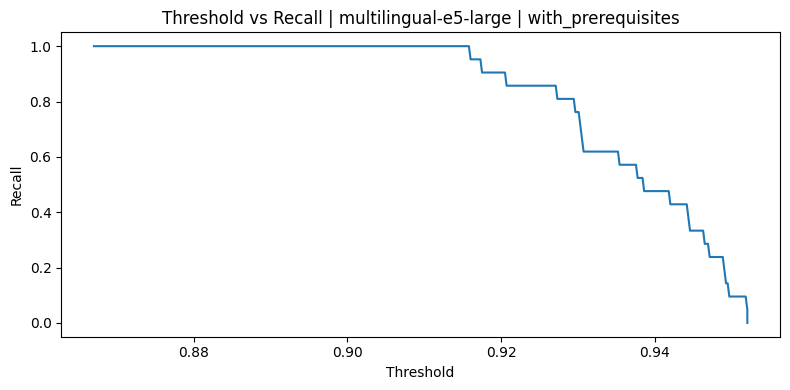

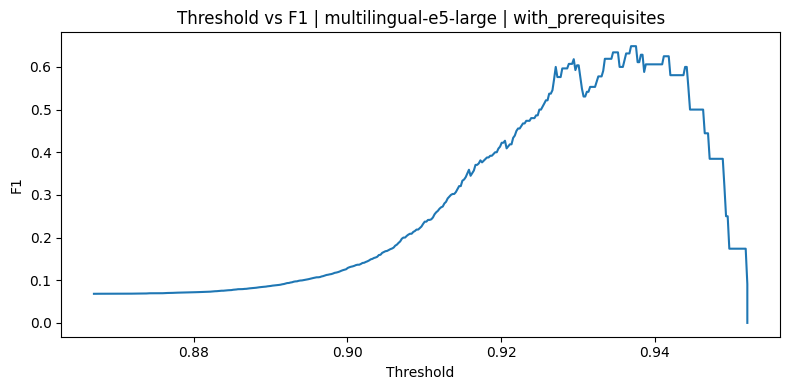

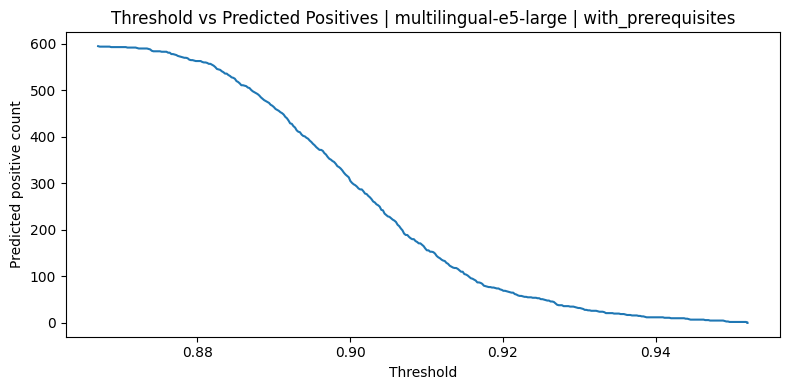

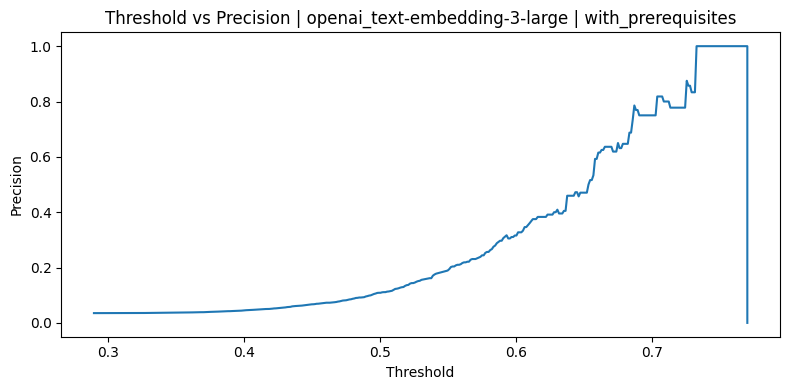

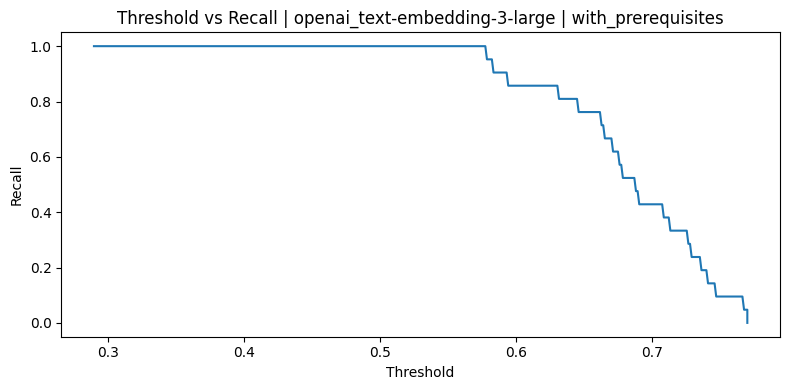

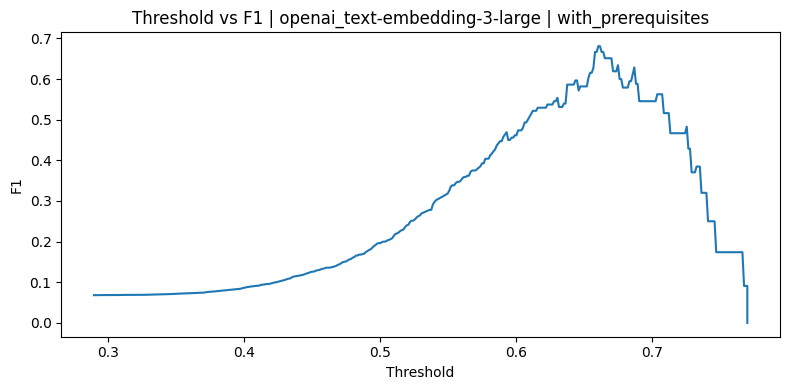

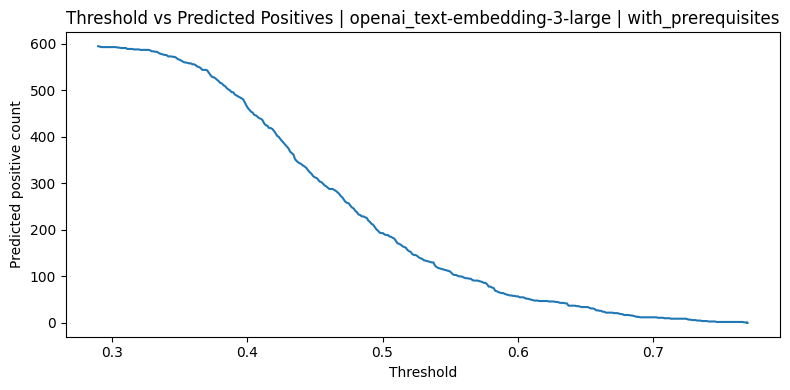

In [45]:
# Cell 19 - Plot threshold behavior for each shortlisted configuration

for (model_name, text_variant), group_df in threshold_scan_dev_df.groupby(["model_name", "text_variant"]):
    plot_df = group_df.sort_values("threshold").reset_index(drop=True)

    # Precision
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["precision"])
    plt.xlabel("Threshold")
    plt.ylabel("Precision")
    plt.title(f"Threshold vs Precision | {model_name} | {text_variant}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_precision_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

    # Recall
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["recall"])
    plt.xlabel("Threshold")
    plt.ylabel("Recall")
    plt.title(f"Threshold vs Recall | {model_name} | {text_variant}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_recall_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

    # F1
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f1"])
    plt.xlabel("Threshold")
    plt.ylabel("F1")
    plt.title(f"Threshold vs F1 | {model_name} | {text_variant}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_f1_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

    # Predicted positives
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["predicted_positive_count"])
    plt.xlabel("Threshold")
    plt.ylabel("Predicted positive count")
    plt.title(f"Threshold vs Predicted Positives | {model_name} | {text_variant}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_predicted_positive_count_{slugify_name(model_name)}__{slugify_name(text_variant)}.png", dpi=150)
    plt.show()

In [46]:
# Cell 20 - Compact development threshold summary for review

dev_threshold_summary_df = candidate_thresholds_dev_df[[
    "model_name",
    "text_variant",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

dev_threshold_summary_df = dev_threshold_summary_df.sort_values(
    ["model_name", "text_variant", "selection_rule"]
).reset_index(drop=True)

dev_threshold_summary_df.to_csv(DEV_THRESHOLD_SUMMARY_CSV_PATH, index=False, encoding="utf-8")

print("Saved development threshold summary to:", DEV_THRESHOLD_SUMMARY_CSV_PATH)
display(dev_threshold_summary_df)

Saved development threshold summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_threshold_summary.csv


,model_name,text_variant,selection_rule,threshold,precision,recall,f1,specificity,predicted_positive_count,tp,fp,fn,tn
0,bge-m3,with_prerequisites,max_f1,0.727691,0.500000,0.761905,0.603774,0.972125,32,16,16,5,558
1,bge-m3,with_prerequisites,precision_first,0.769678,0.888889,0.380952,0.533333,0.998258,9,8,1,13,573
2,bge-m3,with_prerequisites,reviewer_load,0.768803,0.800000,0.380952,0.516129,0.996516,10,8,2,13,572
3,multilingual-e5-base,with_prerequisites,max_f1,0.935257,0.733333,0.523810,0.611111,0.993031,15,11,4,10,570
4,multilingual-e5-base,with_prerequisites,precision_first,0.938345,0.777778,0.333333,0.466667,0.996516,9,7,2,14,572
5,multilingual-e5-base,with_prerequisites,reviewer_load,0.938107,0.700000,0.333333,0.451613,0.994774,10,7,3,14,571
6,multilingual-e5-large,main,max_f1,0.933620,0.909091,0.476190,0.625000,0.998258,11,10,1,11,573
7,multilingual-e5-large,main,precision_first,0.935551,1.000000,0.380952,0.551724,1.000000,8,8,0,13,574
8,multilingual-e5-large,main,reviewer_load,0.934827,0.900000,0.428571,0.580645,0.998258,10,9,1,12,573
9,multilingual-e5-large,with_prerequisites,max_f1,0.936904,0.750000,0.571429,0.648649,0.993031,16,12,4,9,570


### Lock one threshold per shortlisted configuration

The development-set candidate thresholds are now converted into one **locked threshold** per configuration.

Selection logic:

- **OpenAI `text-embedding-3-large` + `with_prerequisites`**  
  use `max_f1`, because it already combines strong precision, useful recall, and manageable reviewer load

- **multilingual-e5-large + `with_prerequisites`**  
  use `precision_first`, because the compressed score range makes the max-F1 threshold too permissive

- **TF-IDF + `with_prerequisites`**  
  use `precision_first`, because the max-F1 threshold produces too many predicted positives

- **BGE-M3 + `compact`**  
  use `precision_first`, because the max-F1 threshold is too reviewer-heavy

- **multilingual-e5-large + `main`**  
  use `precision_first`, to keep the E5 text-variant comparison practically comparable

These locked thresholds are selected on the **development split only** and then applied unchanged to the **test split**.

In [47]:
# Cell 22 - Select one locked threshold per shortlisted configuration

LOCKED_THRESHOLD_RULES = {
    ("openai_text-embedding-3-large", "with_prerequisites"): "max_f1",
    ("multilingual-e5-large", "with_prerequisites"): "precision_first",
    ("tfidf", "with_prerequisites"): "precision_first",
    ("bge-m3", "compact"): "precision_first",
    ("multilingual-e5-large", "main"): "precision_first",
}

selected_threshold_rows = []

for (model_name, text_variant), selection_rule in LOCKED_THRESHOLD_RULES.items():
    match_df = candidate_thresholds_dev_df[
        (candidate_thresholds_dev_df["model_name"] == model_name) &
        (candidate_thresholds_dev_df["text_variant"] == text_variant) &
        (candidate_thresholds_dev_df["selection_rule"] == selection_rule)
    ].copy()

    if match_df.empty:
        raise ValueError(
            f"No candidate threshold found for model={model_name}, text_variant={text_variant}, "
            f"selection_rule={selection_rule}."
        )

    selected_row = match_df.iloc[0].to_dict()
    selected_threshold_rows.append(selected_row)

selected_thresholds_df = pd.DataFrame(selected_threshold_rows)

selected_thresholds_df = selected_thresholds_df[[
    "model_name",
    "text_variant",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

selected_thresholds_df = selected_thresholds_df.sort_values(
    ["f1", "precision", "recall"],
    ascending=[False, False, False]
).reset_index(drop=True)

selected_thresholds_df.to_csv(SELECTED_THRESHOLDS_CSV_PATH, index=False, encoding="utf-8")

print("Saved selected thresholds to:", SELECTED_THRESHOLDS_CSV_PATH)
display(selected_thresholds_df)

ValueError: No candidate threshold found for model=tfidf, text_variant=with_prerequisites, selection_rule=precision_first.

### Evaluate locked thresholds on the test split

The selected thresholds are now applied to the **test split only**.

Important:
- the test set was **not** used to choose these thresholds
- test metrics are therefore a held-out evaluation
- because the test set contains only **5 positive pairs**, results must be interpreted cautiously

In [48]:
# Cell 24 - Evaluate locked thresholds on the test split

test_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "test"].copy()

if test_scores_df.empty:
    raise ValueError("Test split is empty after shortlist filtering.")

test_evaluation_rows = []

for _, threshold_row in selected_thresholds_df.iterrows():
    model_name = threshold_row["model_name"]
    text_variant = threshold_row["text_variant"]
    locked_threshold = float(threshold_row["threshold"])

    group_df = test_scores_df[
        (test_scores_df["model_name"] == model_name) &
        (test_scores_df["text_variant"] == text_variant)
    ].copy()

    if group_df.empty:
        raise ValueError(f"No test rows found for model={model_name}, text_variant={text_variant}.")

    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    metrics = compute_threshold_metrics(y_true=y_true, y_score=y_score, threshold=locked_threshold)

    test_evaluation_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "selection_rule": threshold_row["selection_rule"],
        "locked_threshold": locked_threshold,
        "pair_count_test": len(group_df),
        "positive_count_test": int(group_df["overlap_label_binary"].sum()),
        **metrics,
    })

test_evaluation_df = pd.DataFrame(test_evaluation_rows)

TEST_EVALUATION_CSV_PATH = TABLES_DIR / "test_evaluation_locked_thresholds.csv"
test_evaluation_df.to_csv(TEST_EVALUATION_CSV_PATH, index=False, encoding="utf-8")

print("Saved test evaluation table to:", TEST_EVALUATION_CSV_PATH)
display(test_evaluation_df)

ValueError: No test rows found for model=tfidf, text_variant=with_prerequisites.

### Compare development and test stability

This comparison shows how each locked threshold behaves from development to test.

The goal is not only to find the highest development F1, but to see:

- which thresholds generalize best
- which thresholds become unstable on test
- which models remain practically usable under held-out evaluation

In [49]:
# Cell 26 - Compare dev and test metrics for the locked thresholds

dev_locked_df = selected_thresholds_df.rename(columns={
    "threshold": "dev_locked_threshold",
    "precision": "dev_precision",
    "recall": "dev_recall",
    "f1": "dev_f1",
    "accuracy": "dev_accuracy",
    "specificity": "dev_specificity",
    "predicted_positive_count": "dev_predicted_positive_count",
    "tp": "dev_tp",
    "fp": "dev_fp",
    "fn": "dev_fn",
    "tn": "dev_tn",
})

test_locked_df = test_evaluation_df.rename(columns={
    "precision": "test_precision",
    "recall": "test_recall",
    "f1": "test_f1",
    "accuracy": "test_accuracy",
    "specificity": "test_specificity",
    "predicted_positive_count": "test_predicted_positive_count",
    "tp": "test_tp",
    "fp": "test_fp",
    "fn": "test_fn",
    "tn": "test_tn",
})

dev_test_comparison_df = dev_locked_df.merge(
    test_locked_df,
    on=["model_name", "text_variant", "selection_rule"],
    how="inner",
)

dev_test_comparison_df["precision_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_precision"] - dev_test_comparison_df["dev_precision"]
)
dev_test_comparison_df["recall_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_recall"] - dev_test_comparison_df["dev_recall"]
)
dev_test_comparison_df["f1_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_f1"] - dev_test_comparison_df["dev_f1"]
)

DEV_TEST_COMPARISON_CSV_PATH = TABLES_DIR / "dev_test_threshold_comparison.csv"
dev_test_comparison_df.to_csv(DEV_TEST_COMPARISON_CSV_PATH, index=False, encoding="utf-8")

print("Saved dev/test threshold comparison to:", DEV_TEST_COMPARISON_CSV_PATH)

display(dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "test_precision",
    "test_recall",
    "test_f1",
    "precision_delta_test_minus_dev",
    "recall_delta_test_minus_dev",
    "f1_delta_test_minus_dev",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]])

Saved dev/test threshold comparison to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_test_threshold_comparison.csv


,model_name,text_variant,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,test_precision,test_recall,test_f1,precision_delta_test_minus_dev,recall_delta_test_minus_dev,f1_delta_test_minus_dev,dev_predicted_positive_count,test_predicted_positive_count
0,openai_text-embedding-3-large,with_prerequisites,max_f1,0.686539,0.769231,0.434783,0.555556,1.000000,0.6,0.750000,0.230769,0.165217,0.194444,13,3
1,multilingual-e5-large,with_prerequisites,precision_first,0.944561,0.875000,0.304348,0.451613,1.000000,0.6,0.750000,0.125000,0.295652,0.298387,8,3
2,tfidf,with_prerequisites,precision_first,0.339013,0.777778,0.304348,0.437500,0.571429,0.8,0.666667,-0.206349,0.495652,0.229167,9,7
3,multilingual-e5-large,main,precision_first,0.935068,0.636364,0.304348,0.411765,1.000000,0.6,0.750000,0.363636,0.295652,0.338235,11,3
4,bge-m3,compact,precision_first,0.741682,0.538462,0.304348,0.388889,1.000000,0.8,0.888889,0.461538,0.495652,0.500000,13,4


### Practical interpretation for the PoC

A good threshold is not only one that scores well mathematically.

It should also be practical for a curriculum reviewer:

- predicted positive count should be manageable
- false positives should not dominate the review load
- threshold behavior should be reasonably stable
- the reported overlaps should be interpretable enough to support the later UI

In [50]:
# Cell 28 - Practical threshold interpretation table

practical_interpretation_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_predicted_positive_count",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_predicted_positive_count",
    "test_fp",
    "test_fn",
    "test_tp",
]].copy()

practical_interpretation_df = practical_interpretation_df.sort_values(
    ["test_f1", "test_precision", "dev_f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

PRACTICAL_INTERPRETATION_CSV_PATH = TABLES_DIR / "practical_threshold_interpretation.csv"
practical_interpretation_df.to_csv(PRACTICAL_INTERPRETATION_CSV_PATH, index=False, encoding="utf-8")

print("Saved practical interpretation table to:", PRACTICAL_INTERPRETATION_CSV_PATH)
display(practical_interpretation_df)

Saved practical interpretation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\practical_threshold_interpretation.csv


,model_name,text_variant,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_predicted_positive_count,test_precision,test_recall,test_f1,test_predicted_positive_count,test_fp,test_fn,test_tp
0,bge-m3,compact,precision_first,0.741682,0.538462,0.304348,0.388889,13,1.000000,0.8,0.888889,4,0,1,4
1,openai_text-embedding-3-large,with_prerequisites,max_f1,0.686539,0.769231,0.434783,0.555556,13,1.000000,0.6,0.750000,3,0,2,3
2,multilingual-e5-large,with_prerequisites,precision_first,0.944561,0.875000,0.304348,0.451613,8,1.000000,0.6,0.750000,3,0,2,3
3,multilingual-e5-large,main,precision_first,0.935068,0.636364,0.304348,0.411765,11,1.000000,0.6,0.750000,3,0,2,3
4,tfidf,with_prerequisites,precision_first,0.339013,0.777778,0.304348,0.437500,9,0.571429,0.8,0.666667,7,3,1,4


### Final threshold winner decision

The final winner should not be chosen using development AP alone.

It should combine:

- Notebook 03 ranking quality
- Notebook 04 threshold behavior on development
- held-out test behavior
- practical reviewer usability

Because the test set contains only 5 positives, the result should be interpreted as a **careful PoC recommendation**, not as a final production guarantee.

In [51]:
# Cell 30 - Final threshold winner summary with balanced thesis interpretation

final_ranking_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "test_precision",
    "test_recall",
    "test_f1",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]].copy()

final_ranking_df = final_ranking_df.sort_values(
    ["test_f1", "test_precision", "dev_f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(final_ranking_df)

print("Final thesis-oriented interpretation:")
print()

print("Primary recommendation:")
print("  openai_text-embedding-3-large + with_prerequisites")
print("  Reason: strongest overall combination of Notebook 03 ranking quality,")
print("  large positive-vs-negative score separation, strong development threshold")
print("  behavior, and solid held-out test performance.")
print()

print("Strong held-out alternative:")
print("  bge-m3 + compact")
print("  Reason: best test-set threshold result in this split, but weaker overall")
print("  evidence from Notebook 03 and weaker development-set threshold behavior.")
print("  Because the test split contains only 5 positives, this result should be")
print("  treated as promising rather than definitive.")
print()

print("Important tradeoff:")
print("  multilingual-e5-large remains competitive in ranking metrics, but its")
print("  compressed score range makes thresholding more fragile in practice.")
print()

print("Lexical baseline finding:")
print("  TF-IDF remains competitive, showing that exact domain vocabulary overlap")
print("  is genuinely informative in this corpus.")
print()

print("Final recommendation for the PoC UI:")
print("  Use openai_text-embedding-3-large + with_prerequisites as the primary")
print("  overlap-scoring configuration, and report BGE-M3 as a noteworthy")
print("  alternative result in the thesis discussion.")

,model_name,text_variant,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,test_precision,test_recall,test_f1,dev_predicted_positive_count,test_predicted_positive_count
0,bge-m3,compact,precision_first,0.741682,0.538462,0.304348,0.388889,1.000000,0.8,0.888889,13,4
1,openai_text-embedding-3-large,with_prerequisites,max_f1,0.686539,0.769231,0.434783,0.555556,1.000000,0.6,0.750000,13,3
2,multilingual-e5-large,with_prerequisites,precision_first,0.944561,0.875000,0.304348,0.451613,1.000000,0.6,0.750000,8,3
3,multilingual-e5-large,main,precision_first,0.935068,0.636364,0.304348,0.411765,1.000000,0.6,0.750000,11,3
4,tfidf,with_prerequisites,precision_first,0.339013,0.777778,0.304348,0.437500,0.571429,0.8,0.666667,9,7


Final thesis-oriented interpretation:

Primary recommendation:
  openai_text-embedding-3-large + with_prerequisites
  Reason: strongest overall combination of Notebook 03 ranking quality,
  large positive-vs-negative score separation, strong development threshold
  behavior, and solid held-out test performance.

Strong held-out alternative:
  bge-m3 + compact
  Reason: best test-set threshold result in this split, but weaker overall
  evidence from Notebook 03 and weaker development-set threshold behavior.
  Because the test split contains only 5 positives, this result should be
  treated as promising rather than definitive.

Important tradeoff:
  multilingual-e5-large remains competitive in ranking metrics, but its
  compressed score range makes thresholding more fragile in practice.

Lexical baseline finding:
  TF-IDF remains competitive, showing that exact domain vocabulary overlap
  is genuinely informative in this corpus.

Final recommendation for the PoC UI:
  Use openai_text-emb

## Final note

Notebook 04 turns similarity scores into thresholded overlap decisions for the shortlisted configurations from Notebook 03.

### What this notebook does well
- selects thresholds using development data only
- preserves a held-out test evaluation
- compares multiple threshold strategies
- highlights practical tradeoffs between precision, recall, and reviewer load
- connects benchmark ranking quality to real overlap-flagging behavior

### Important limitations
- the test split contains only 5 positive pairs
- small changes in threshold behavior may therefore change test metrics noticeably
- results should be interpreted as strong PoC evidence rather than final production-grade calibration

Together, Notebook 03 and Notebook 04 provide a defensible answer to the thesis question of which model and threshold combination best balances precision and recall for curriculum overlap detection.

In [21]:
# Cell XX - Load original labeled pair file for detailed inspection cells

PAIRS_CSV_PATH = DATA_DIR / "gold_pairs_review_labeled.csv"

pairs_df = pd.read_csv(PAIRS_CSV_PATH, encoding="utf-8", keep_default_na=False)

if "overlap_label_binary" not in pairs_df.columns:
    def normalize_overlap_label(value):
        text = str(value).strip().lower()
        if text in {"1", "true", "yes", "overlap"}:
            return 1
        if text in {"0", "false", "no", "none", "no overlap"}:
            return 0
        return np.nan

    pairs_df["overlap_label_binary"] = pairs_df["overlap_label"].apply(normalize_overlap_label)

print("pairs_df shape:", pairs_df.shape)
display(pairs_df.head(2))

pairs_df shape: (1225, 11)


,pair_id,course_unit_code_1,course_name_1,review_text_1,course_unit_code_2,course_name_2,review_text_2,overlap_label,review_status,review_notes,overlap_label_binary
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD71,Linux Basics,"Course code: TT00CD71 | Course name: Linux Basics | Objective: After completing the course, you will understand the most important concepts of the Linux ope...",0,reviewed,,0
1,TT00CD70__TT00CD72,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD72,Servers and containers,Course code: TT00CD72 | Course name: Servers and containers | Objective: You understand the fundamental types and functions of servers. You understand the k...,0,reviewed,,0


In [22]:
# Cell XX - Show OpenAI false negatives on the test split
# Definition: overlap_label_binary = 1 and predicted_overlap = 0

OPENAI_MODEL_NAME = "openai_text-embedding-3-large"
OPENAI_TEXT_VARIANT = "with_prerequisites"

openai_threshold_row = selected_thresholds_df[
    (selected_thresholds_df["model_name"] == OPENAI_MODEL_NAME) &
    (selected_thresholds_df["text_variant"] == OPENAI_TEXT_VARIANT)
].copy()

if openai_threshold_row.empty:
    raise ValueError("No locked threshold found for OpenAI with_prerequisites.")

openai_locked_threshold = float(openai_threshold_row.iloc[0]["threshold"])
print("OpenAI locked threshold:", openai_locked_threshold)

openai_test_df = evaluation_scores_df[
    (evaluation_scores_df["split"] == "test") &
    (evaluation_scores_df["model_name"] == OPENAI_MODEL_NAME) &
    (evaluation_scores_df["text_variant"] == OPENAI_TEXT_VARIANT)
].copy()

if openai_test_df.empty:
    raise ValueError("No OpenAI test rows found in evaluation_scores_df.")

openai_test_df["predicted_overlap"] = (
    openai_test_df["similarity_score"] >= openai_locked_threshold
).astype(int)

# Merge back full pair details from pairs_df
pair_detail_columns = [
    "pair_id",
    "course_unit_code_1",
    "course_name_1",
    "review_text_1",
    "course_unit_code_2",
    "course_name_2",
    "review_text_2",
    "overlap_label_binary",
    "review_notes",
    "split",
]

available_pair_detail_columns = [col for col in pair_detail_columns if col in pairs_df.columns]

openai_test_df = openai_test_df.merge(
    pairs_df[available_pair_detail_columns].drop_duplicates(subset=["pair_id"]),
    on="pair_id",
    how="left",
    suffixes=("", "_pairfile")
)

# Prefer original pair-file label/split columns if merge produced duplicates
if "overlap_label_binary_pairfile" in openai_test_df.columns:
    openai_test_df["overlap_label_binary"] = openai_test_df["overlap_label_binary_pairfile"]
if "split_pairfile" in openai_test_df.columns:
    openai_test_df["split"] = openai_test_df["split_pairfile"]

openai_test_false_negatives_df = openai_test_df[
    (openai_test_df["overlap_label_binary"] == 1) &
    (openai_test_df["predicted_overlap"] == 0)
].copy()

openai_test_false_negatives_df = openai_test_false_negatives_df.sort_values(
    "similarity_score",
    ascending=False
).reset_index(drop=True)

OPENAI_TEST_FALSE_NEGATIVES_PATH = TABLES_DIR / "openai_false_negatives_test.csv"
openai_test_false_negatives_df.to_csv(OPENAI_TEST_FALSE_NEGATIVES_PATH, index=False, encoding="utf-8")

print("Number of OpenAI false negatives on test:", len(openai_test_false_negatives_df))
print("Saved to:", OPENAI_TEST_FALSE_NEGATIVES_PATH)

display(openai_test_false_negatives_df[[
    "pair_id",
    "course_unit_code_1",
    "course_name_1",
    "course_unit_code_2",
    "course_name_2",
    "overlap_label_binary",
    "predicted_overlap",
    "similarity_score",
    "review_notes",
    "review_text_1",
    "review_text_2",
]])

OpenAI locked threshold: 0.6865392893478088
Number of OpenAI false negatives on test: 2
Saved to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\openai_false_negatives_test.csv


,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,predicted_overlap,similarity_score,review_notes,review_text_1,review_text_2
0,TT00CE14__TT00CE16,TT00CE14,Malware Analysis,TT00CE16,Reverse Engineering,1,0,0.662126,"Both involve low-level executable analysis, including static/dynamic investigation of compiled code and behavior.","Course code: TT00CE14 | Course name: Malware Analysis | Objective: The course focuses on the analysis of malware, emphasizing dynamic analysis methods and t...","Course code: TT00CE16 | Course name: Reverse Engineering | Objective: After completing the course, the student understands the basic concepts of reverse eng..."
1,TT00CD99__TT00CE00,TT00CD99,Data Sources and Data Preprocessing,TT00CE00,Data Analysis and Visualization,1,0,0.631063,"Both include data cleaning, preprocessing, and practical analysis workflow steps.",Course code: TT00CD99 | Course name: Data Sources and Data Preprocessing | Objective: Data preprocessing is an essential part of data analytics and machine ...,Course code: TT00CE00 | Course name: Data Analysis and Visualization | Objective: Data analysis and visualization are needed in solutions to both data-based...
